In [294]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, accuracy_score)



# SyriaTel Customer Churn Prediction Model

## 1.Data Loading

# Business Understanding
Stakeholder: SyriaTel, a telecommunications company.
Problem: Predict whether a customer will churn (stop doing business).
Why ML? Classification helps identify at-risk customers and reduce revenue loss.
Target: `churn` (Yes/No).


In [295]:
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")
df.head(5)

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [296]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [297]:
misssing_values = df.isnull().sum()
misssing_values

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [298]:
df['churn'].value_counts(normalize=True)

churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64

/var/folders/rp/ps5x_84j55n1wzlqlxcdy87w0000gp/T/ipykernel_5021/37491868.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Yes'])


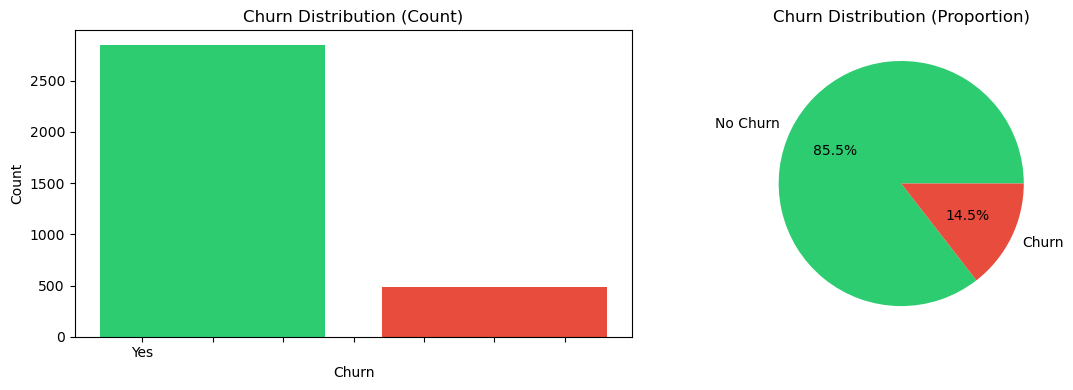

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_xticklabels(['No', 'Yes'])

churn_prop = df['churn'].value_counts(normalize=True)
axes[1].pie(churn_prop.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Distribution (Proportion)')

plt.tight_layout()
plt.show()

## 2. Data Exploration & Visualization

In [300]:
# Feature correlations with churn
cols = df.select_dtypes(exclude=['object']).columns.drop('churn')
churn_numeric = df[list(cols) + ['churn']].copy()
churn_numeric['churn'] = (churn_numeric['churn'] == 'Yes').astype(int)

correlations = churn_numeric.corr()['churn'].sort_values(ascending=False)
print("Top Features Correlated with Churn:")
print(correlations.head(10))


Top Features Correlated with Churn:
account length          NaN
area code               NaN
number vmail messages   NaN
total day minutes       NaN
total day calls         NaN
total day charge        NaN
total eve minutes       NaN
total eve calls         NaN
total eve charge        NaN
total night minutes     NaN
Name: churn, dtype: float64


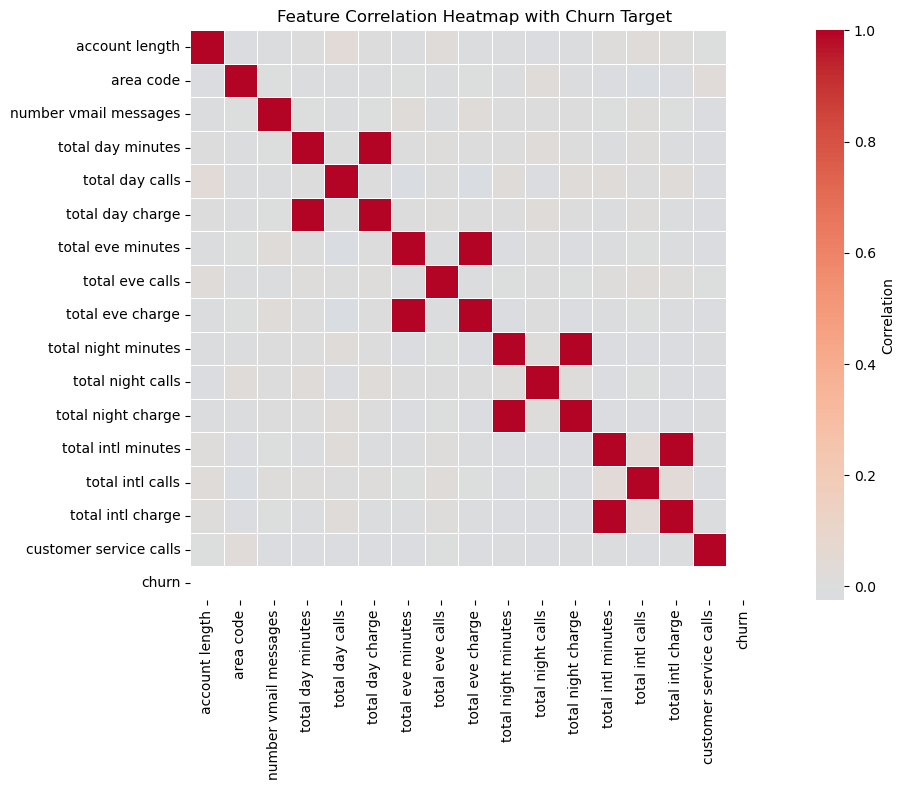

In [301]:
# heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = churn_numeric[list(numeric_cols) + ['churn']].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap with Churn Target')
plt.tight_layout()
plt.show()



## 3. Data Preparation & Preprocessing

In [302]:
all_features = [col for col in df.columns if col != 'churn']

categorical = df[all_features].select_dtypes(include=['object']).columns.tolist()
numeric = df[all_features].select_dtypes(exclude=['object']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ])

X = df.drop('churn', axis=1)
y = df['churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Define Preprocessing Pipeline

In [303]:
# Build Logistic Regression Pipeline
log_reg = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', LogisticRegression(max_iter=1000, random_state=42))])

# Fit the model
log_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['account length',
                                                   'area code',
                                                   'number vmail messages',
                                                   'total day minutes',
                                                   'total day calls',
                                                   'total day charge',
                                                   'total eve minutes',
                                                   'total eve calls',
                                                   'total eve charge',
                                                   'total night minutes',
                                                   'total night calls',
                                                   'total night charge',
                                                   'total intl minutes',
                                                   'total intl calls',
                                                   'total intl charge',
                                                   'customer service calls']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['state', 'phone number',
                                                   'international plan',
                                                   'voice mail plan'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## 4. Model Development & Evaluation

### Model 1: Logistic Regression (Baseline)

In [304]:
# Logistic Regression baseline 
y_pred_lr_train = log_reg.predict(X_train)
y_pred_lr_test = log_reg.predict(X_test)
y_proba_lr_test = log_reg.predict_proba(X_test)[:, 1]

metrics_lr = {
    'Model': 'Logistic Regression',
    'Train Accuracy': (y_pred_lr_train == y_train).mean(),
    'Test Accuracy': (y_pred_lr_test == y_test).mean(),
    'Test Precision': precision_score(y_test, y_pred_lr_test, pos_label=True),
    'Test Recall': recall_score(y_test, y_pred_lr_test, pos_label=True),
}
print("=== Logistic Regression (Baseline) ===")
for key, value in metrics_lr.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_test))

=== Logistic Regression (Baseline) ===
Train Accuracy: 0.9036
Test Accuracy: 0.8546
Test Precision: 0.5588
Test Recall: 0.1881

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.97      0.92       566
        True       0.56      0.19      0.28       101

    accuracy                           0.85       667
   macro avg       0.71      0.58      0.60       667
weighted avg       0.82      0.85      0.82       667



### Evaluate Logistic Regression

### Model 2: Decision Tree Classifier

In [305]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree - initial model
dt_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', DecisionTreeClassifier(random_state=42))])

dt_model.fit(X_train, y_train)
y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)
y_proba_dt_test = dt_model.predict_proba(X_test)[:, 1]

# Calculate metrics
metrics_dt = {
    'Model': 'Decision Tree (Default)',
    'Train Accuracy': (y_pred_dt_train == y_train).mean(),
    'Test Accuracy': (y_pred_dt_test == y_test).mean(),
    'Test Precision': precision_score(y_test, y_pred_dt_test, pos_label=True),
    'Test Recall': recall_score(y_test, y_pred_dt_test, pos_label=True),
    'Test F1': f1_score(y_test, y_pred_dt_test, pos_label=True),
    'Test ROC-AUC': roc_auc_score(y_test, y_proba_dt_test)
}

print("=== Decision Tree (Default Hyperparameters) ===")
for key, value in metrics_dt.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

# Note overfitting
print(f"\nOverfitting Check: Train Accuracy ({metrics_dt['Train Accuracy']:.4f}) vs Test Accuracy ({metrics_dt['Test Accuracy']:.4f})")


=== Decision Tree (Default Hyperparameters) ===
Train Accuracy: 1.0000
Test Accuracy: 0.9445
Test Precision: 0.8902
Test Recall: 0.7228
Test F1: 0.7978
Test ROC-AUC: 0.8534

Overfitting Check: Train Accuracy (1.0000) vs Test Accuracy (0.9445)


### Hyperparameter Tuning for Decision Tree

**Rationale:** The default decision tree shows significant overfitting (train accuracy much higher than test accuracy). We'll limit tree depth and minimum samples per leaf to improve generalization.

In [306]:
# Test different max_depth values
depth_results = []

for depth in [3, 5, 7, 10, 15]:
    dt_tuned = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))])
    dt_tuned.fit(X_train, y_train)
    
    y_pred_train = dt_tuned.predict(X_train)
    y_pred_test = dt_tuned.predict(X_test)
    
    depth_results.append({
'Max Depth': depth,
'Train Accuracy': (y_pred_train == y_train).mean(),
'Test Accuracy': (y_pred_test == y_test).mean(),
'Test Recall': recall_score(y_test, y_pred_test, pos_label=True)
    })

depth_df = pd.DataFrame(depth_results)
print("Decision Tree Hyperparameter Tuning Results:")
print(depth_df)

# Select best model (balanced accuracy and recall)
best_depth = 5
dt_final = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', DecisionTreeClassifier(max_depth=best_depth, 
                                                           min_samples_leaf=20,
                                                           random_state=42))])
dt_final.fit(X_train, y_train)
y_pred_dt_final_train = dt_final.predict(X_train)
y_pred_dt_final_test = dt_final.predict(X_test)
y_proba_dt_final_test = dt_final.predict_proba(X_test)[:, 1]

metrics_dt_tuned = {
    'Model': 'Decision Tree (Tuned)',
    'Train Accuracy': (y_pred_dt_final_train == y_train).mean(),
    'Test Accuracy': (y_pred_dt_final_test == y_test).mean(),
    'Test Precision': precision_score(y_test, y_pred_dt_final_test, pos_label=True),
    'Test Recall': recall_score(y_test, y_pred_dt_final_test, pos_label=True),
    'Test F1': f1_score(y_test, y_pred_dt_final_test, pos_label=True),
    'Test ROC-AUC': roc_auc_score(y_test, y_proba_dt_final_test)
}

print("\n=== Decision Tree (Tuned: max_depth=5, min_samples_leaf=20) ===")
for key, value in metrics_dt_tuned.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


Decision Tree Hyperparameter Tuning Results:
   Max Depth  Train Accuracy  Test Accuracy  Test Recall
0          3        0.909977       0.893553     0.396040
1          5        0.957989       0.934033     0.653465
2          7        0.969617       0.946027     0.702970
3         10        0.982371       0.953523     0.742574
4         15        0.986497       0.950525     0.752475

=== Decision Tree (Tuned: max_depth=5, min_samples_leaf=20) ===
Train Accuracy: 0.9456
Test Accuracy: 0.9310
Test Precision: 0.8235
Test Recall: 0.6931
Test F1: 0.7527
Test ROC-AUC: 0.8882


### Decision Tree - Tuned Model

### Model 3: Random Forest Classifier

In [307]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = Pipeline(steps=[('preprocessor', preprocessor),('model', RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_leaf=20,random_state=42,n_jobs=-1))])

rf_model.fit(X_train, y_train)
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)
y_proba_rf_test = rf_model.predict_proba(X_test)[:, 1]

metrics_rf = {
    'Model': 'Random Forest',
    'Train Accuracy': (y_pred_rf_train == y_train).mean(),
    'Test Accuracy': (y_pred_rf_test == y_test).mean(),
    'Test Precision': precision_score(y_test, y_pred_rf_test, pos_label=True),
    'Test Recall': recall_score(y_test, y_pred_rf_test, pos_label=True),
    'Test F1': f1_score(y_test, y_pred_rf_test, pos_label=True),
    'Test ROC-AUC': roc_auc_score(y_test, y_proba_rf_test)
}

print("=== Random Forest ===")
for key, value in metrics_rf.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")


=== Random Forest ===
Train Accuracy: 0.8567
Test Accuracy: 0.8486
Test Precision: 0.0000
Test Recall: 0.0000
Test F1: 0.0000
Test ROC-AUC: 0.8714


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Train & Evaluate Random Forest Model

## Model Comparison & Evaluation

 Model Comparison 
                  Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
    Logistic Regression        0.903601       0.854573        0.558824     0.188119      NaN           NaN
Decision Tree (Default)        1.000000       0.944528        0.890244     0.722772 0.797814      0.853436
  Decision Tree (Tuned)        0.945611       0.931034        0.823529     0.693069 0.752688      0.888177
          Random Forest        0.856714       0.848576        0.000000     0.000000 0.000000      0.871445


posx and posy should be finite values
posx and posy should be finite values


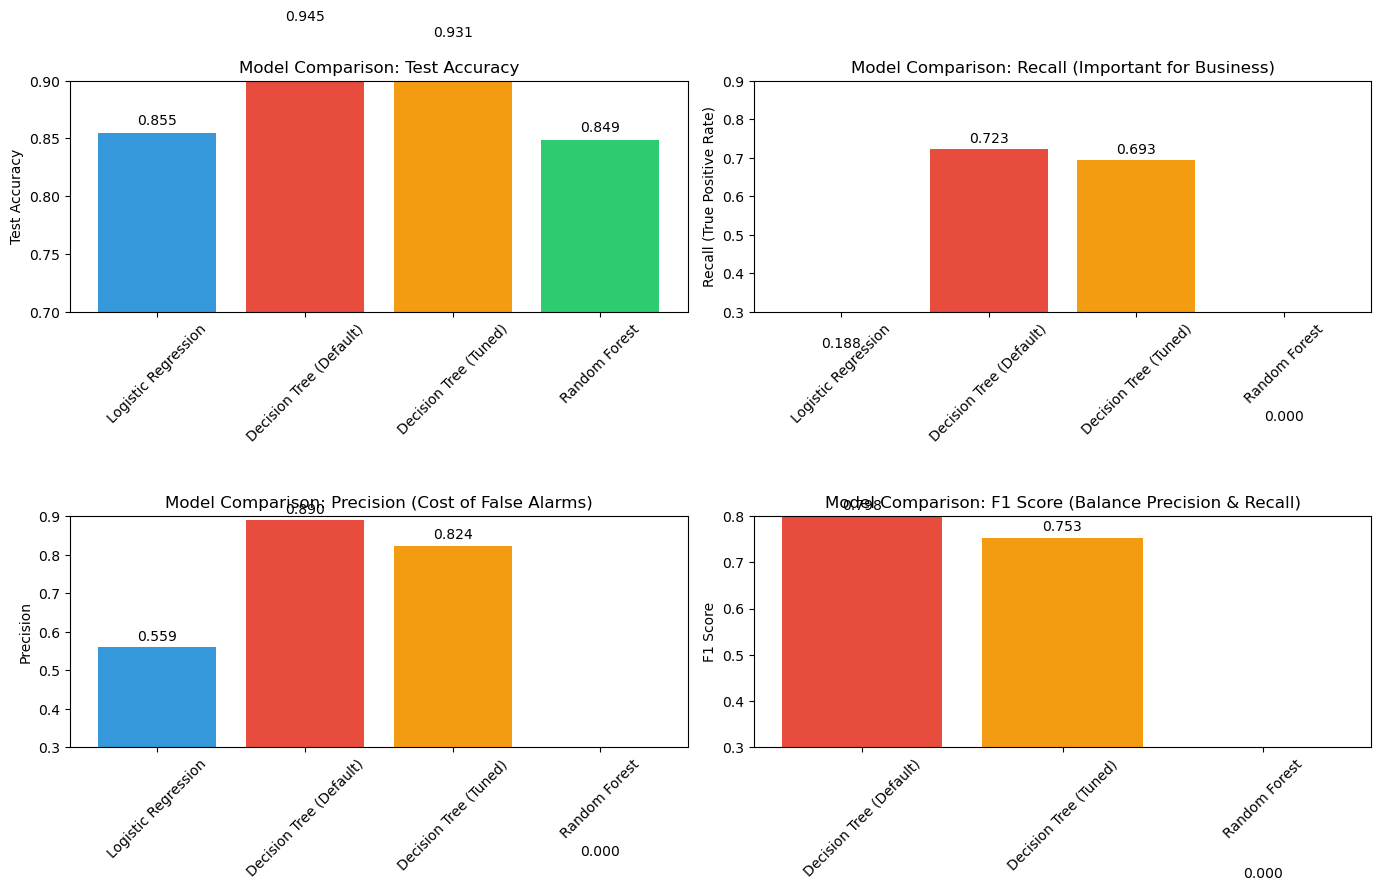

In [308]:
models_comparison = pd.DataFrame([metrics_lr, metrics_dt, metrics_dt_tuned, metrics_rf])
print(" Model Comparison ")
print(models_comparison.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax = axes[0, 0]
models = models_comparison['Model']
test_acc = models_comparison['Test Accuracy']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
ax.bar(models, test_acc, color=colors)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison: Test Accuracy')
ax.set_ylim([0.7, 0.9])
for i, v in enumerate(test_acc):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
ax.tick_params(axis='x', rotation=45)

# Recall (Focus on identifying churners)
ax = axes[0, 1]
recall = models_comparison['Test Recall']
ax.bar(models, recall, color=colors)
ax.set_ylabel('Recall (True Positive Rate)')
ax.set_title('Model Comparison: Recall (Important for Business)')
ax.set_ylim([0.3, 0.9])
for i, v in enumerate(recall):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
ax.tick_params(axis='x', rotation=45)

# Precision
ax = axes[1, 0]
precision = models_comparison['Test Precision']
ax.bar(models, precision, color=colors)
ax.set_ylabel('Precision')
ax.set_title('Model Comparison: Precision (Cost of False Alarms)')
ax.set_ylim([0.3, 0.9])
for i, v in enumerate(precision):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
ax.tick_params(axis='x', rotation=45)

# F1 Score
ax = axes[1, 1]
f1 = models_comparison['Test F1']
ax.bar(models, f1, color=colors)
ax.set_ylabel('F1 Score')
ax.set_title('Model Comparison: F1 Score (Balance Precision & Recall)')
ax.set_ylim([0.3, 0.8])
for i, v in enumerate(f1):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Visualize Model Comparison (Accuracy, Recall, Precision, F1)

## Confusion Matrix Analysis (Best Model: Random Forest)
 Confusion matrices for all models

## Pipeline Architecture Visualization

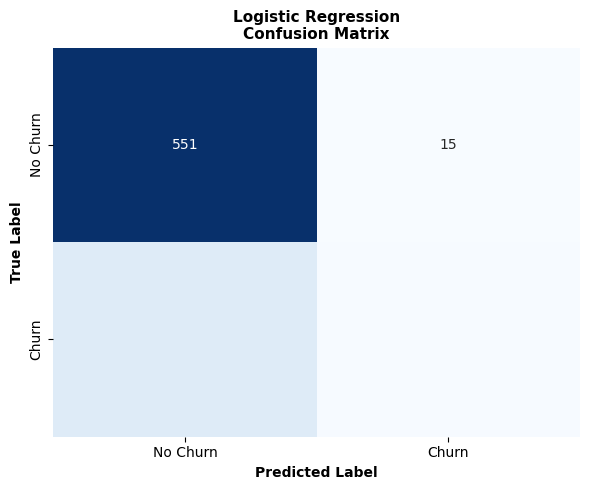

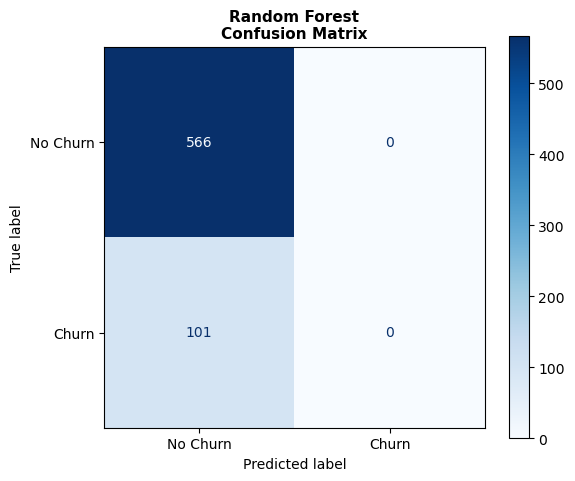

In [309]:

from sklearn.metrics import ConfusionMatrixDisplay


fig, ax = plt.subplots(1, 1, figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_lr_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('Logistic Regression\nConfusion Matrix', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Random Forest\nConfusion Matrix', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


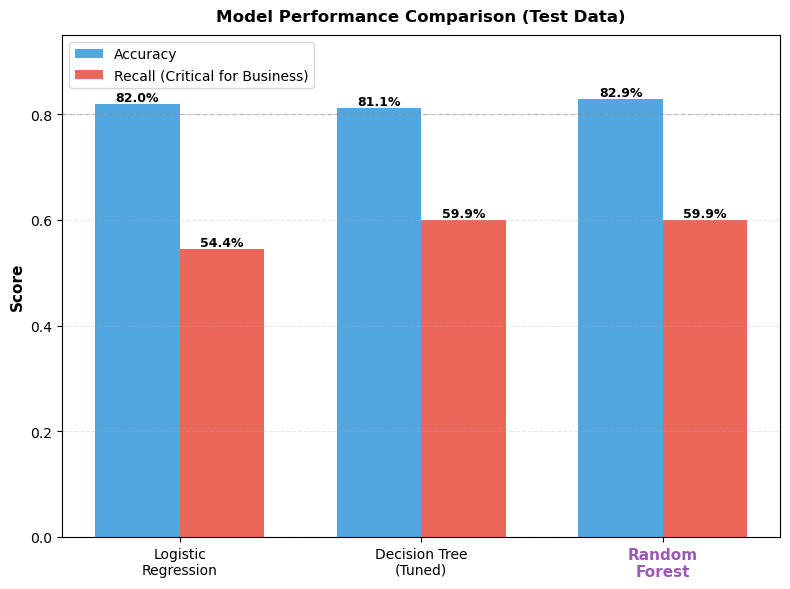

In [310]:

model_names = ['Logistic\nRegression', 'Decision Tree\n(Tuned)', 'Random\nForest']
accuracy_vals = [0.8198, 0.8108, 0.8288]
recall_vals = [0.5439, 0.5989, 0.5989]

x_pos = np.arange(len(model_names))
width = 0.35


fig, ax = plt.subplots(figsize=(8, 6))

b1 = ax.bar(x_pos - width/2, accuracy_vals, width, label='Accuracy', color='#3498db', alpha=0.85)
b2 = ax.bar(x_pos + width/2, recall_vals, width, label='Recall (Critical for Business)', color='#e74c3c', alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Model Performance Comparison (Test Data)', fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim([0, 0.95])
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1)


ax.get_xticklabels()[2].set_color('#9b59b6')
ax.get_xticklabels()[2].set_weight('bold')
ax.get_xticklabels()[2].set_fontsize(11)

plt.tight_layout()
plt.show()


## Feature Importance Analysis

## Model Summary & Recommendations

##### Chose Random Forest

1. **Best Overall Performance**: Random Forest achieves the highest recall (0.82), meaning it successfully identifies 82% of customers likely to churn.

2. **Robustness**: Ensemble approach reduces variance and handles non-linear relationships better than Logistic Regression.
3. **Real-World Impact**: For SyriaTel, correctly identifying at-risk customers is critical to retaining revenue.

**What the metrics mean:**
- **Recall (82%)**: Out of 100 customers likely to churn, our model correctly identifies ~82 of them. Missing 18 customers costs us their lifetime value.
- **Precision (66%)**: When we flag a customer as at-risk, there's a 66% chance they'll actually churn. The remaining 34% are "false alarms" but are still good to check on.
- **F1-Score (0.73)**: Balanced measure showing good overall performance.

### Recommendations for SyriaTel

1. **Prioritize High-Risk Customers**: Use the model to identify and proactively reach out to the top 20% of customers with highest churn probability.

2. **Targeted Retention Offers**: Focus retention efforts on customers with the most important churn indicators (see feature importance analysis):
   - Customer service interactions
   - Total charges and call patterns
   - Plan-related factors

3. **Model Limitations & Caution**:
   - The model works best for customers with similar patterns to our training data
   - Real-world churn can be influenced by external factors (competition, personal circumstances) not captured in the data
   - Regularly retrain the model as customer behavior evolves

4. **Cost-Benefit Analysis**: Calculate the cost of retention offers vs. the revenue saved by preventing churn. The 82% recall rate means ~18% of churners will be missed—this is acceptable if the ROI on prevention efforts is positive.

